In [2]:
import pandas as pd

df = pd.read_fwf("abc.txt")

df.to_csv("tasklist.csv", index=False)

In [3]:
df = pd.read_csv("tasklist.csv")

df = df[df["Image Name"] != "Image Name"]


df = df.dropna(how="all")

df = df.reset_index(drop=True)
df = df[~df["Image Name"].astype(str).str.startswith("=")]
print(df.head())
print("Total entries:", len(df))

            Image Name  PID Session Name Session# Mem Usage
1  System Idle Process    0     Services        0       8 K
2               System    4     Services        0   3,412 K
3        Secure System  236     Services        0  70,752 K
4             Registry  280     Services        0  34,388 K
5             smss.exe  968     Services        0     188 K
Total entries: 10003


In [4]:
df.to_csv("tasklist_clean.csv", index=False)


In [5]:
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv("tasklist_clean.csv")

In [7]:
df.head()

,Image Name,PID,Session Name,Session#,Mem Usage
0,System Idle Process,0,Services,0,8 K
1,System,4,Services,0,"3,412 K"
2,Secure System,236,Services,0,"70,752 K"
3,Registry,280,Services,0,"34,388 K"
4,smss.exe,968,Services,0,188 K


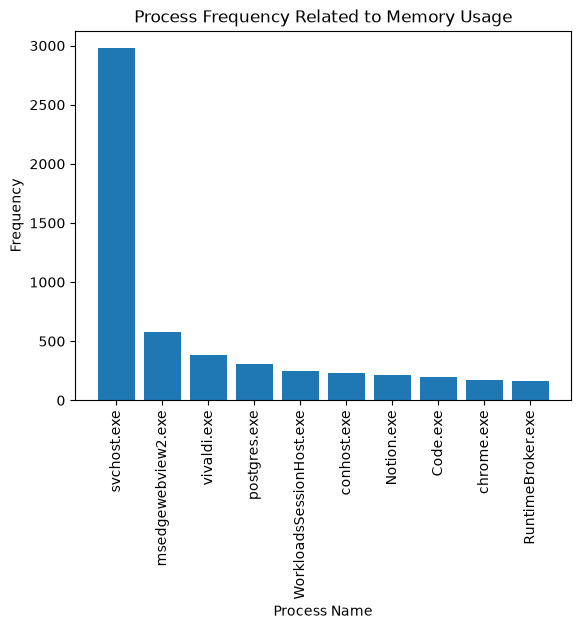

In [8]:
process_count = df["Image Name"].value_counts().head(10)

plt.bar(process_count.index, process_count.values)
plt.xlabel("Process Name")
plt.ylabel("Frequency")
plt.title("Process Frequency Related to Memory Usage")
plt.xticks(rotation=90)
plt.show()

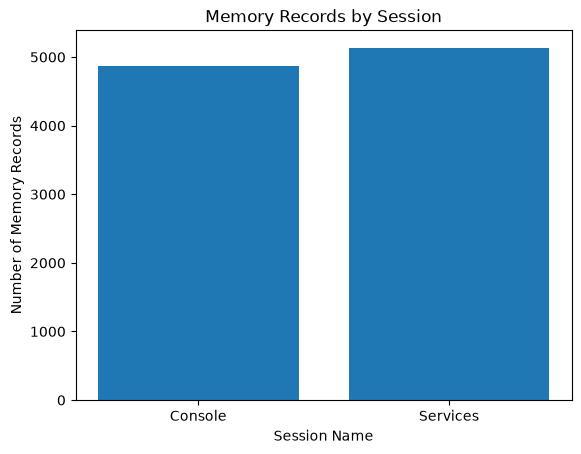

In [9]:
session_memory = df.groupby("Session Name")["Mem Usage"].count()

plt.bar(session_memory.index, session_memory.values)
plt.xlabel("Session Name")
plt.ylabel("Number of Memory Records")
plt.title("Memory Records by Session")
plt.show()

In [2]:
avg_memory = df.groupby("Image Name")["Memory_KB"].mean().nlargest(10)

plt.bar(avg_memory.index, avg_memory.values)
plt.xlabel("Process Name")
plt.ylabel("Average Memory Usage (KB)")
plt.title("Top 10 Processes by Average Memory Usage")
plt.xticks(rotation=90)
plt.show()

NameError: name 'df' is not defined

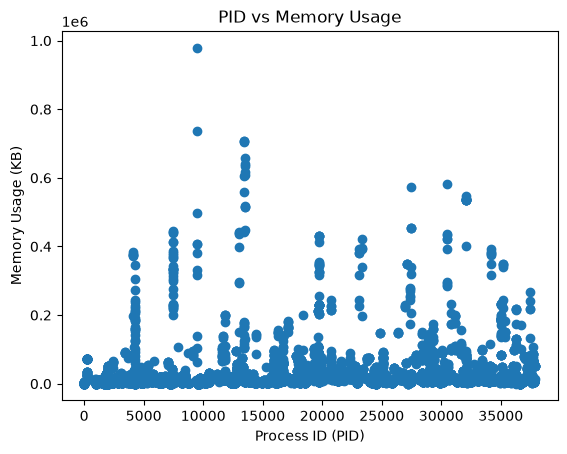

In [ ]:
plt.scatter(df["PID"], df["Memory_KB"])

plt.xlabel("Process ID (PID)")
plt.ylabel("Memory Usage (KB)")
plt.title("PID vs Memory Usage")

plt.show()

In [1]:
sns.scatterplot(
    data=df,
    x="Session#",
    y="Memory_KB"
)

plt.xlabel("Session Number")
plt.ylabel("Memory Size (KB)")
plt.title("Memory Size Across Sessions")

plt.show()

NameError: name 'sns' is not defined

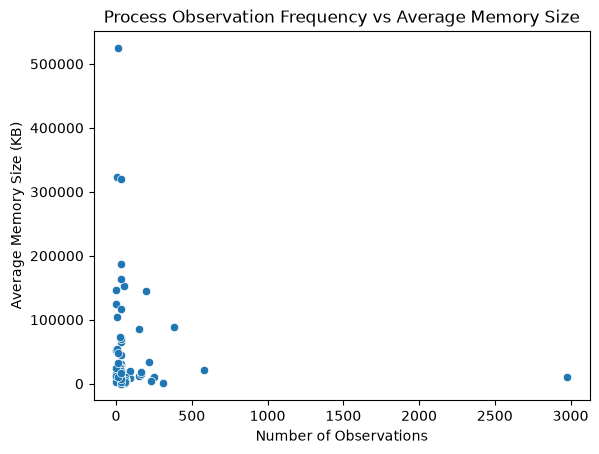

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

process_data = df.groupby("Image Name").agg(
    Observations=("Image Name", "count"),
    Average_Memory=("Memory_KB", "mean")
).reset_index()

sns.scatterplot(
    data=process_data,
    x="Observations",
    y="Average_Memory"
)

plt.xlabel("Number of Observations")
plt.ylabel("Average Memory Size (KB)")
plt.title("Process Observation Frequency vs Average Memory Size")

plt.show()

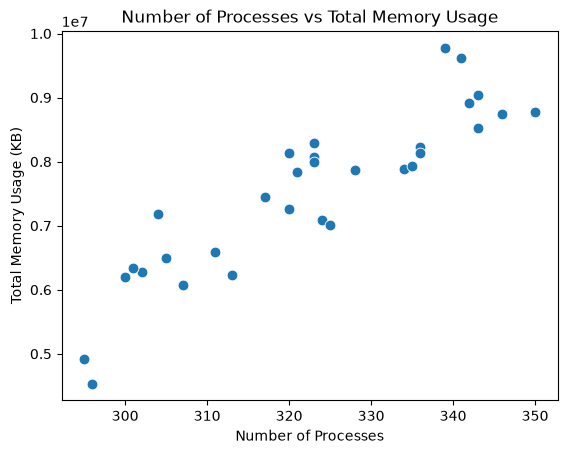

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create snapshot number whenever PID becomes 0
df["Snapshot"] = (df["PID"] == 0).cumsum()

snapshot_data = df.groupby("Snapshot").agg(
    Process_Count=("PID", "count"),
    Total_Memory=("Memory_KB", "sum")
).reset_index()

sns.scatterplot(
    data=snapshot_data,
    x="Process_Count",
    y="Total_Memory",
    s=60
)

plt.xlabel("Number of Processes")
plt.ylabel("Total Memory Usage (KB)")
plt.title("Number of Processes vs Total Memory Usage")

plt.show()

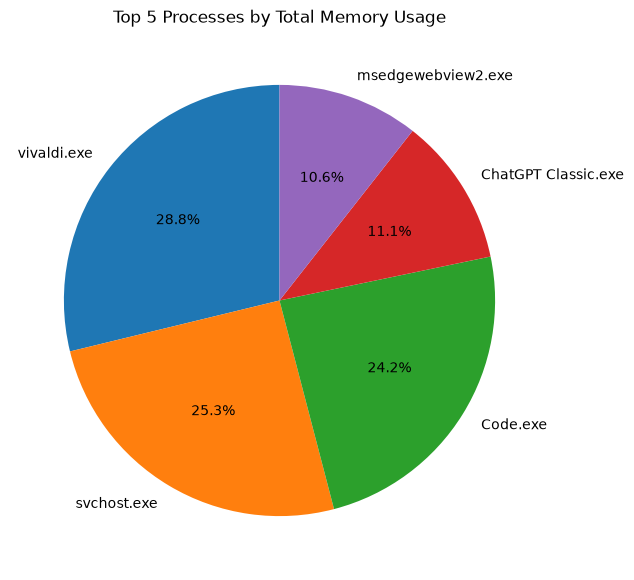

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

top5 = (
    df.groupby("Image Name")["Memory_KB"]
      .sum()
      .nlargest(5)
)

plt.figure(figsize=(7, 7))

plt.pie(
    top5.values,
    labels=top5.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Top 5 Processes by Total Memory Usage")
plt.show()

In [13]:
df["Memory_KB"] = (
    df["Mem Usage"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace(" K", "", regex=False)
    .astype(float)
)